# Relatório Técnico: Descobrindo as Melhores Oportunidades de Investimentos em Aluguéis Temporários

Uma empresa interessada em investir no mercado de aluguéis temporários em Nova York nos contratou para identificar os melhores locais para aquisição de imóveis. Para isso, analisamos os dados de alguns dos maiores concorrentes, buscando padrões que indicassem alta rentabilidade.


## 1. Introdução
Este relatório apresenta uma analise detalhada dos dados de listagens do Airbnb em Nova York. Foram realizadas etapas de limpeza, tratamento de dados, análise exploratória e visualização de informações relevantes para entender a distribuição e os preços das acomodações na cidade.

## 2. Configuração do Ambiente
Antes de iniciar a análise, foi realizada a configuração do ambiente com as bibliotecas necessárias:


*   **Pandas** e **NumPy** para manipulação e análise dos dados;
*   **Matplotlib** para visualização gráfica;


*   **Collections** para contagem de elementos dentro do dataset.





In [ ]:
import matplotlib.image as mpimg
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from typing import Dict
import pandas as pd
import numpy as np
import math

## 3. Coleta de dados
Os dados foram obtidos a partir do conjunto de dados públicos do Airbnb para Nova York. O dataset contém informações sobre as listagens, incluindo localização, preço, tipo de acomodação e avaliações.

In [ ]:
import pandas as pd
df = pd.read_csv(' https://data.insideairbnb.com/united-states/ny/new-york-city/2025-01-03/visualisations/listings.csv')

## 4. Limpeza e Tratamento de Dados
Foram realizadas etapas de limpeza para remover valores ausentes  e padronizar os dados. Isso inclui:


*   Preenchimento de valores ausentes em colunas críticas;
*   Conversão de colunas para os tipos adequados (por exemplo, preços para valores numéricos).



In [ ]:
df.fillna({'name': 'nameless'}, inplace=True)
df.fillna({'host_name': 'host_nameless'}, inplace=True)
df.fillna({'reviews_per_month': 0}, inplace=True)
df.fillna({'last_review': 0}, inplace=True)
df['last_review'] = pd.to_datetime(df['last_review'], format='%Y-%m-%d', errors='coerce')
df['price'] = df.groupby(['neighbourhood', 'room_type'])['price'].transform(lambda x: x.fillna(x.median()))
df['price'] = df['price'].fillna(df['price'].median())

## 5. Análise Exploratória
### 5.1 Distribuição de Acomodações por Bairro
Foram analisadas as acomodações por grupo de bairros (neighbourhood_group), visualizando a quantidade de listagens em cada região. O gráfico de contagem das acomodações por bairro revelou a concentração das listagens nos principais distritos da cidade. A seguir, apresentamos um gráfico de barras representando essa distribuição:



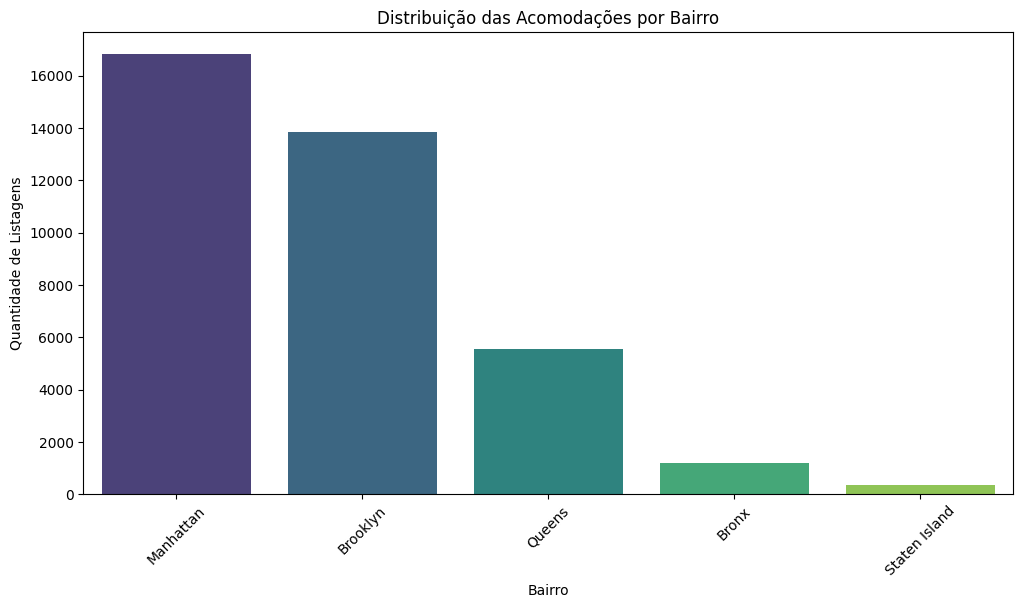

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['neighbourhood_group'], order=df['neighbourhood_group'].value_counts().index, hue=df['neighbourhood_group'], palette="viridis", legend=False)
plt.title('Distribuição das Acomodações por Bairro')
plt.xlabel('Bairro')
plt.ylabel('Quantidade de Listagens')
plt.xticks(rotation=45)
plt.show()

### 5.2 Preço das Acomodações
Foram analises detalhadas de preço por bairro, revelendo tendências como:


*   Há grande variação de preços dentro de cada bairro, indicando a presença de diferentes tipos de acomodações e faixas de preço;

A análise foi complementada por um boxplot, permitindo visualizar a dispersão dos preços em cada região. A seguir, apresentamos esse gráfico:


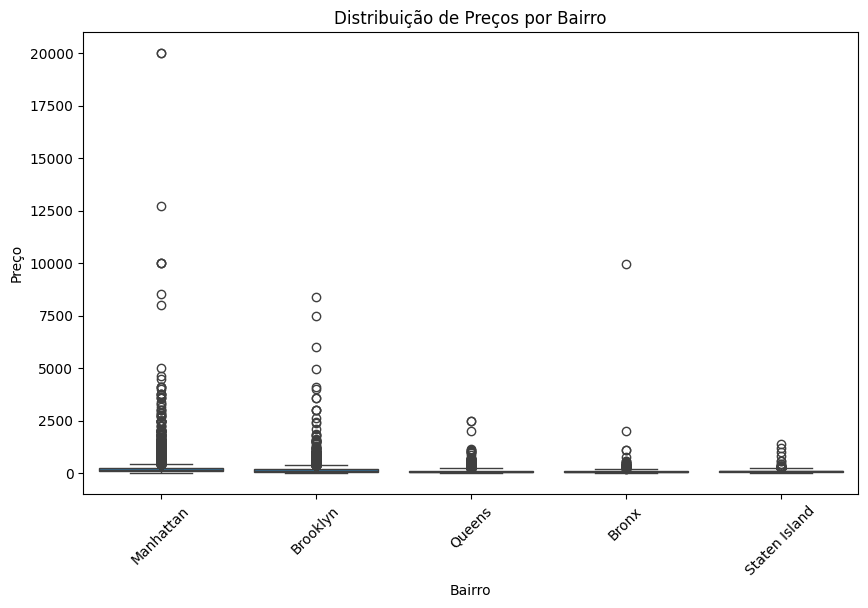

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title('Distribuição de Preços por Bairro')
plt.xlabel('Bairro')
plt.ylabel('Preço')
plt.xticks(rotation=45)
plt.show()

### 5.3 Disponibilidade
A disponibilidade dos anúncios foi estudada ao longo do ano, identificando períodos de alta e baixa ocupação. Para isso, analisamos a distribuição da variável *availability_365*, que representa o número de dias que cada listagem está disponível ao longo do ano.

A seguir, apresentamos um histograma dessa distribuição:

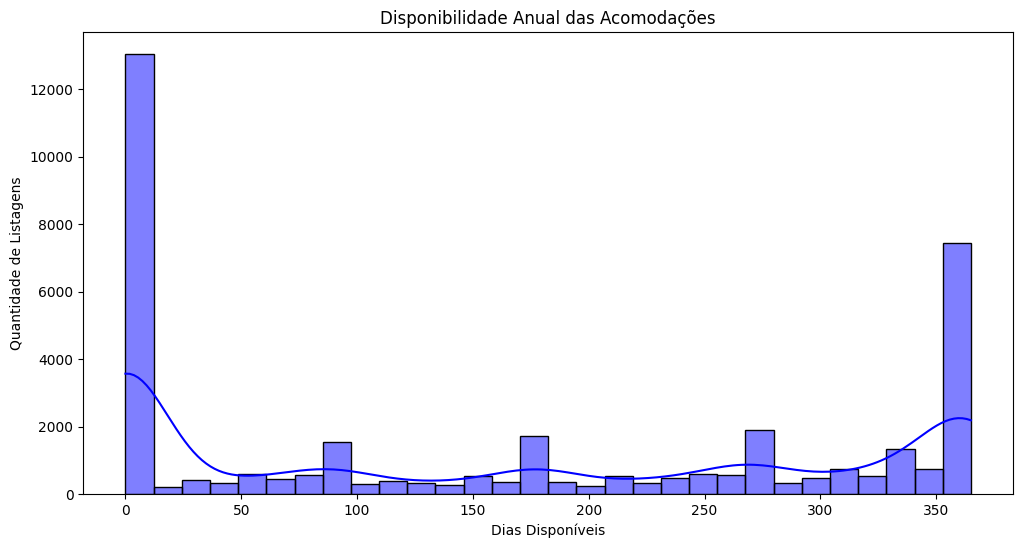

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df['availability_365'], bins=30, kde=True, color='blue')
plt.title('Disponibilidade Anual das Acomodações')
plt.xlabel('Dias Disponíveis')
plt.ylabel('Quantidade de Listagens')
plt.show()

## 6. Conclusão
A análise revelou que a distribuição das acomodações e os preços estão desigualmente distribuídas pelos bairros, com maior concentração em regiões centrais e turísticas.

Regiões mais centrais e turísticas tendem a ter preços mais elevados, enquanto áreas periféricas oferecem opções mais acessíveis.

 A análise da disponibilidade mostrou que muitas acomodações não estão disponiveis o ano todo, sugerindo padrões sazonais ou proprietários que listam os imóveis apenas em determinados períodos.